# CMAPSS Exploratory Data Analysis — FD001

This notebook walks through what NASA's CMAPSS turbofan dataset looks
like *before* any modelling, and motivates each transformation in
`pdm.features`.

The goal: build a clear mental model of the degradation signal so the
choices made later (which sensors to drop, how to relabel RUL, what
rolling windows to use) are grounded in the data, not in convention.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pdm.data import SENSOR_COLUMNS, load_subset
from pdm.features import add_rolling_features, clip_rul, drop_constant_sensors


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Load FD001

FD001 is the simplest of the four CMAPSS subsets: a single operating
regime and a single fault mode. It's the right starting point for an
EDA — anything we can't explain here will only get worse on FD002 / FD004
where multiple regimes and fault modes are mixed.

In [2]:
data = load_subset("FD001", "../data/raw")

print(f"Subset:        {data.subset}")
print(f"Train units:   {data.n_train_units} ({len(data.train):,} rows)")
print(f"Test units:    {data.n_test_units} ({len(data.test):,} rows)")
print(f"Sensors:       {len(SENSOR_COLUMNS)}")
print(f"Train RUL:     {data.train['RUL'].min()} → {data.train['RUL'].max()}")

data.train.head(3)

Subset:        FD001
Train units:   100 (20,631 rows)
Test units:    100 (13,096 rows)
Sensors:       21
Train RUL:     0 → 361


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189


## 2. Trajectory length distribution

Each training unit runs from cycle 1 until failure, but the failure
cycle differs unit-to-unit. The histogram below shows the spread of
trajectory lengths in the training set: the bulk of engines fail
between 150 and 250 cycles, with a long right tail.

That long tail matters: those long-lived engines spend most of their
trajectory in a healthy regime that carries almost no degradation
signal. This is the empirical motivation for piecewise-linear RUL
capping later on.

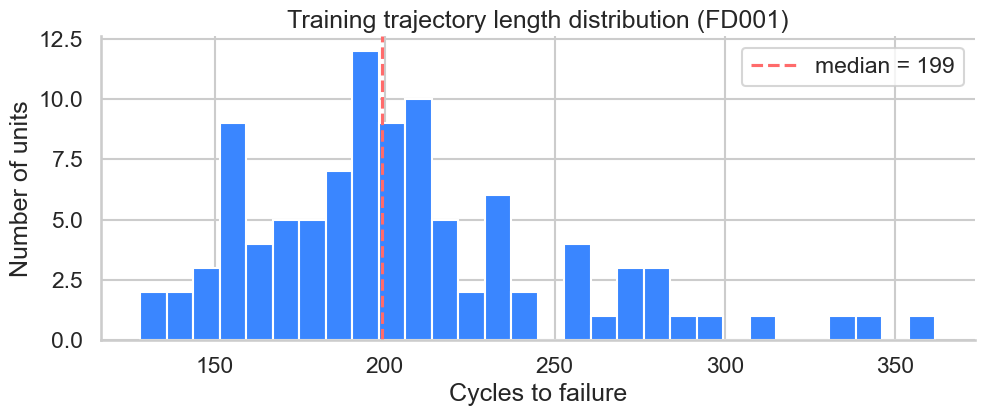

In [3]:
trajectory_lengths = data.train.groupby("unit_id")["cycle"].max()

fig, ax = plt.subplots()
ax.hist(trajectory_lengths, bins=30, color="#3a86ff", edgecolor="white")
ax.axvline(trajectory_lengths.median(), color="#ff6b6b", linestyle="--", label=f"median = {int(trajectory_lengths.median())}")
ax.set_xlabel("Cycles to failure")
ax.set_ylabel("Number of units")
ax.set_title("Training trajectory length distribution (FD001)")
ax.legend()
fig.tight_layout()

## 3. Which sensors actually move?

Of the 21 sensor channels, several are reported as effectively
constant across the entire fleet. They carry zero degradation
information and (for gradient-based learners) just inject numerical
instability. The function `drop_constant_sensors` finds and removes
them automatically — but it's worth seeing the raw evidence.

/var/folders/7d/r6cf110n6hq44kflzvmvmk7r0000gn/T/ipykernel_16560/2153827830.py:11: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/7d/r6cf110n6hq44kflzvmvmk7r0000gn/T/ipykernel_16560/2153827830.py:11: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
/Users/naoyahigashitani/predictive-maintenance-cmapss/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/naoyahigashitani/predictive-maintenance-cmapss/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/naoyahigashitani/predictive-maintenance-cmapss/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(b

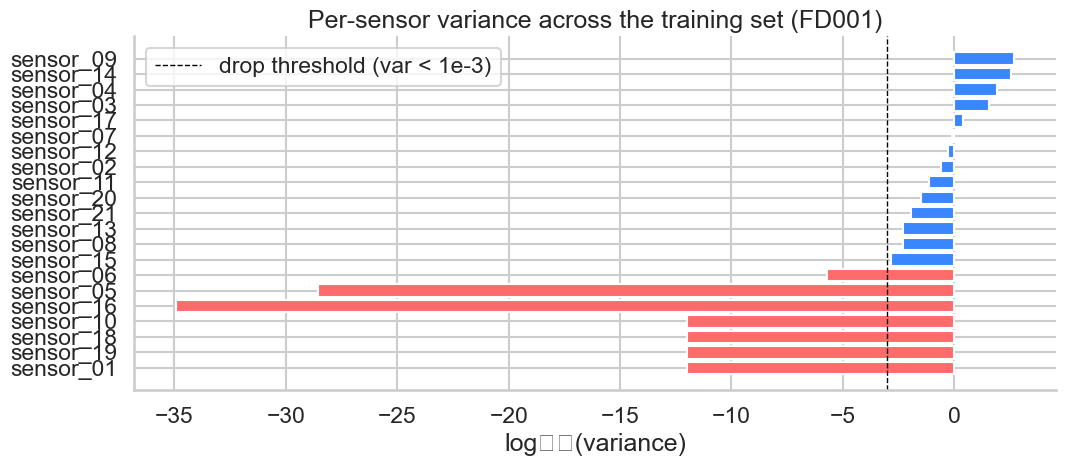

In [4]:
sensor_variances = data.train[list(SENSOR_COLUMNS)].var().sort_values()

fig, ax = plt.subplots(figsize=(11, 5))
log_var = np.log10(sensor_variances.replace(0, 1e-12))
colors = ["#ff6b6b" if v < -3 else "#3a86ff" for v in log_var]
ax.barh(sensor_variances.index, log_var, color=colors)
ax.axvline(-3, color="black", linestyle="--", linewidth=1, label="drop threshold (var < 1e-3)")
ax.set_xlabel("log₁₀(variance)")
ax.set_title("Per-sensor variance across the training set (FD001)")
ax.legend()
fig.tight_layout()

In [5]:
filtered, dropped = drop_constant_sensors(data.train)
print(f"Dropped {len(dropped)} sensors (zero / near-zero variance):")
print(f"  {dropped}")
informative_sensors = [c for c in filtered.columns if c.startswith("sensor_")]
print(f"\nKeeping {len(informative_sensors)} informative sensors.")

Dropped 6 sensors (zero / near-zero variance):
  ['sensor_01', 'sensor_05', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Keeping 15 informative sensors.


## 4. Degradation in a single engine

Pick a representative training unit and overlay its informative
sensors after standardising each one. The visual story is consistent
across engines: noisy but stationary in the early cycles, then a clear
divergence in the last 50–100 cycles as multiple sensors drift toward
their failure values.

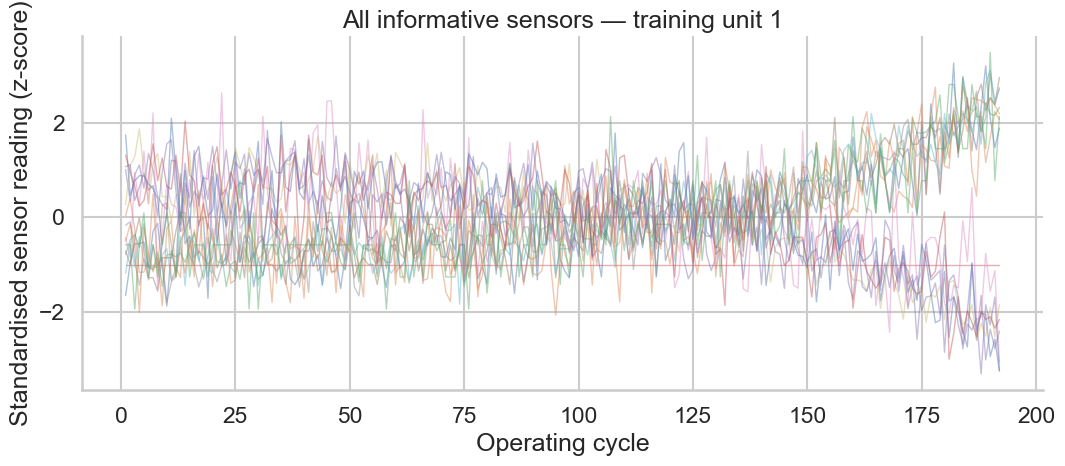

In [6]:
example_unit = 1
unit_df = data.train[data.train["unit_id"] == example_unit].sort_values("cycle")

# Standardise each sensor to make trajectories comparable on one axis.
sensor_z = (unit_df[informative_sensors] - unit_df[informative_sensors].mean()) / unit_df[informative_sensors].std()

fig, ax = plt.subplots(figsize=(11, 5))
for sensor in informative_sensors:
    ax.plot(unit_df["cycle"], sensor_z[sensor], alpha=0.45, linewidth=1)
ax.set_xlabel("Operating cycle")
ax.set_ylabel("Standardised sensor reading (z-score)")
ax.set_title(f"All informative sensors — training unit {example_unit}")
fig.tight_layout()

## 5. Variability across units

Sensor 11 (a high-pressure compressor outlet pressure proxy) is one
of the most informative channels. Plotting it for a sample of training
units, aligned by **cycles to failure** rather than absolute cycle,
shows a clean monotonic drift in the last ~80 cycles before failure.
Whatever the model, it has to capture this end-of-life regime.

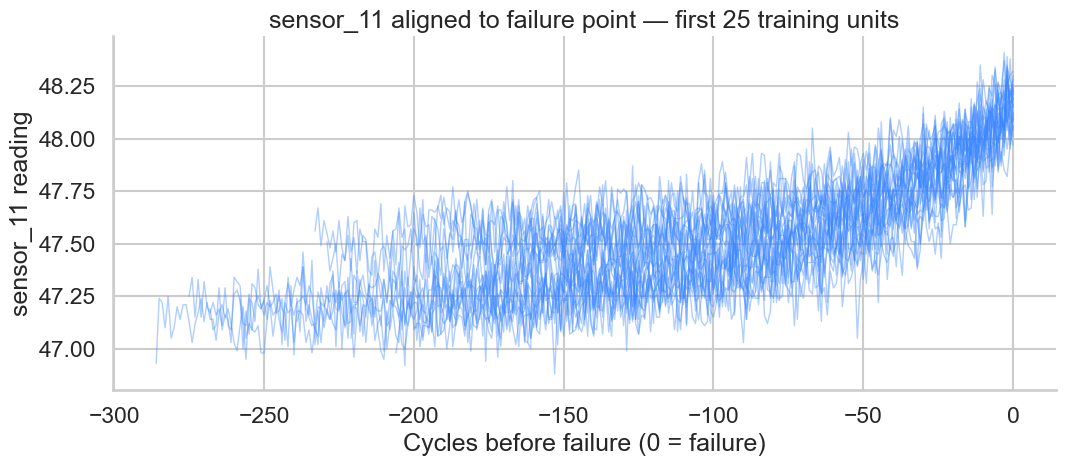

In [7]:
sensor_of_interest = "sensor_11"
sample_units = sorted(data.train["unit_id"].unique())[:25]

fig, ax = plt.subplots(figsize=(11, 5))
for unit in sample_units:
    sub = data.train[data.train["unit_id"] == unit].sort_values("cycle")
    cycles_to_failure = sub["cycle"].max() - sub["cycle"]
    ax.plot(-cycles_to_failure, sub[sensor_of_interest], alpha=0.4, color="#3a86ff", linewidth=1)
ax.set_xlabel("Cycles before failure (0 = failure)")
ax.set_ylabel(f"{sensor_of_interest} reading")
ax.set_title(f"{sensor_of_interest} aligned to failure point — first 25 training units")
fig.tight_layout()

## 6. RUL distribution and piecewise-linear capping

Because trajectories run to failure, the raw training RUL is uniform
in `[0, max_cycle_per_unit]`. The histogram is therefore extremely
skewed: many cycles have a "remaining life" of 200+, but during those
early cycles the degradation hasn't really begun.

Capping the RUL target at, e.g., 125 cycles forces the model to
concentrate capacity on the regime where degradation is observable —
a relabelling convention introduced by Heimes (2008) and used in
essentially every competitive CMAPSS submission since.

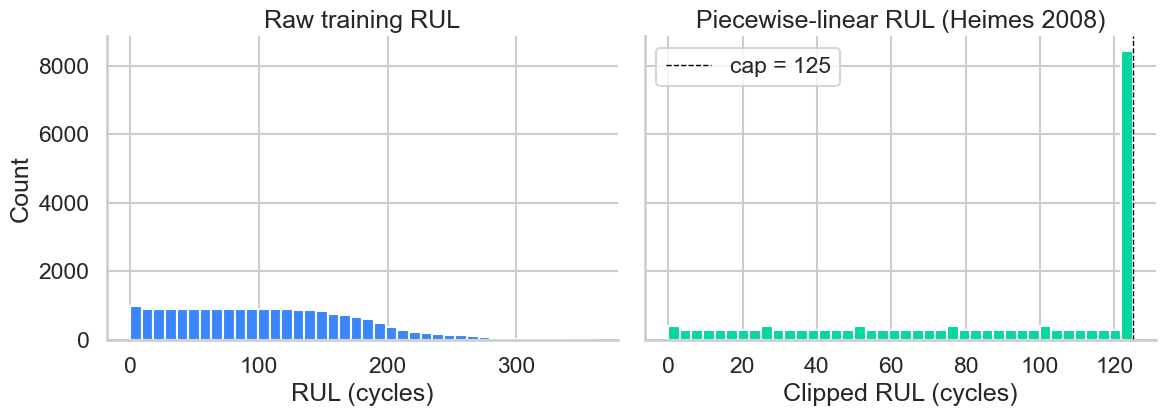

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].hist(data.train["RUL"], bins=40, color="#3a86ff", edgecolor="white")
axes[0].set_title("Raw training RUL")
axes[0].set_xlabel("RUL (cycles)")
axes[0].set_ylabel("Count")

clipped = clip_rul(data.train["RUL"], max_rul=125)
axes[1].hist(clipped, bins=40, color="#06d6a0", edgecolor="white")
axes[1].axvline(125, color="black", linestyle="--", linewidth=1, label="cap = 125")
axes[1].set_title("Piecewise-linear RUL (Heimes 2008)")
axes[1].set_xlabel("Clipped RUL (cycles)")
axes[1].legend()
fig.tight_layout()

## 7. Rolling smoothing

Raw sensor readings are noisy — the per-cycle variability often dwarfs
the cycle-to-cycle drift. A short rolling mean recovers the underlying
degradation curve without obscuring its shape, while a longer window
(here 20 cycles) reveals the macro trend that the regression target
is ultimately asking the model to predict.

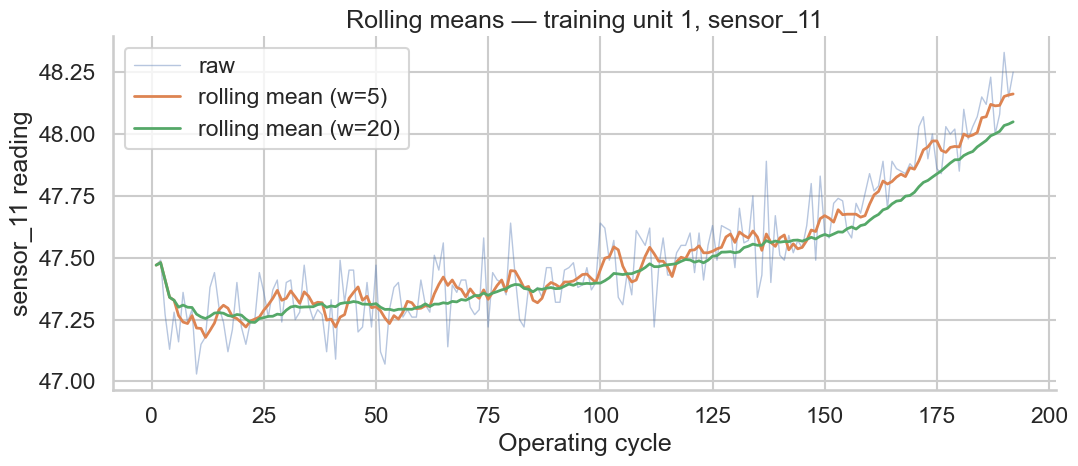

In [9]:
rolled = add_rolling_features(
    data.train,
    windows=(5, 20),
    columns=[sensor_of_interest],
    statistics=("mean",),
)
unit_rolled = rolled[rolled["unit_id"] == example_unit].sort_values("cycle")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(unit_rolled["cycle"], unit_rolled[sensor_of_interest], alpha=0.4, label="raw", linewidth=1)
ax.plot(unit_rolled["cycle"], unit_rolled[f"{sensor_of_interest}_mean_5"], label="rolling mean (w=5)", linewidth=2)
ax.plot(unit_rolled["cycle"], unit_rolled[f"{sensor_of_interest}_mean_20"], label="rolling mean (w=20)", linewidth=2)
ax.set_xlabel("Operating cycle")
ax.set_ylabel(f"{sensor_of_interest} reading")
ax.set_title(f"Rolling means — training unit {example_unit}, {sensor_of_interest}")
ax.legend()
fig.tight_layout()

## 8. Sensor correlation structure

Many of the informative sensors carry redundant information, which is
exactly what we'd expect from a thermodynamic system: pressures,
temperatures, and rotational speeds along the same flow path move
together. The block structure in the heatmap below suggests there's
room for a dimensionality-reduction step (e.g., PCA) before passing
features to the model.

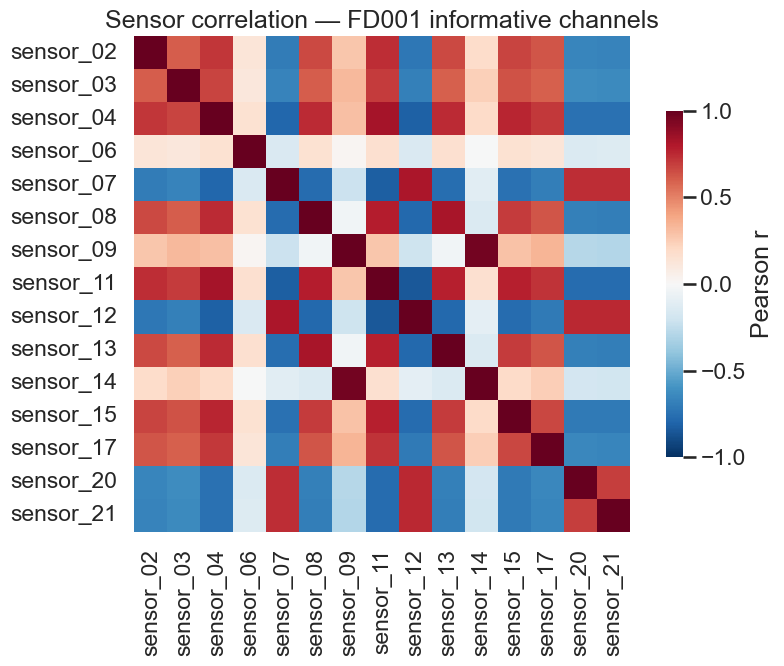

In [10]:
corr = data.train[informative_sensors].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Sensor correlation — FD001 informative channels")
fig.tight_layout()

## What we learned

1. **Trajectory lengths span 130 – 360+ cycles**, with a long tail of
   long-lived engines whose early cycles carry no useful signal.
2. **Seven sensors are constants** across the fleet and can be dropped
   without loss of information.
3. **Degradation is concentrated in the last ~80 cycles**; sensors
   drift monotonically once the failure regime begins.
4. **Capping RUL at 125** matches the empirical regime where the
   signal is observable and avoids fitting noise in healthy cycles.
5. **Rolling means with w = 5–20** preserve the degradation curve
   while suppressing high-frequency noise.
6. **Strong correlations** among the informative channels point to a
   low intrinsic dimensionality.

The next notebook will use these insights to fit a baseline RUL
regressor and benchmark a sequence model against it.